# Nanocrystal Detection : End-to-End Pipeline

This notebook walks through the full pipeline developed at Efrei Paris in collaboration with INNOLabto classify calcium carbonate nanocrystals from SEM microscope images.

**Goal:** Automate identification of nanocrystal morphology (cubic / pseudo-cubic / ball) to accelerate materials research for sustainable construction.

**Pipeline:**
1. Unsupervised clustering : explore morphology groups without labels (VGG16 + PCA + KMeans)
2. Manual annotation : draw bounding boxes on raw SEM images
3. Data augmentation : generate synthetic training images via patch pasting
4. YOLOv8 training : object detection on 3 classes
5. Results : metrics and visualizations

> **Note:** Cells that require the full dataset are marked with `[requires dataset]`. The dataset is not included in this repo, see `data/README.md`.

---
## 0. Setup

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from PIL import Image

# Make src/ importable from the notebook
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
# or if running from repo root:
sys.path.insert(0, 'src')

REPO_ROOT = os.path.dirname(os.path.abspath('.'))
print('Working directory:', os.getcwd())

Working directory: C:\Users\ulyss\OneDrive\Documents\nanocristals-ai\notebooks


---
## 1. Unsupervised Clustering

Before any annotation, we ran unsupervised clustering on all SEM images to understand the natural morphology groups and guide our class definition.

**Method:**
- Crop the instrument metadata bar from the bottom of each .bmp image
- Extract deep features with **VGG16** (ImageNet pre-trained, no classification head)
- Reduce dimensionality with **PCA**
- Cluster with **KMeans**
- Sort images into per-cluster folders for visual inspection

We ran this experiment at **two zoom levels** to check whether morphology separates consistently across magnifications.

### 1.1 Preprocessing : crop metadata bar

SEM images have an instrument info bar at the bottom. We crop it to avoid it influencing features.  
Crop zone: `(0, 0, 1228, 750)` pixels for the images in this dataset.

`[requires dataset]`

In [ ]:
from clustering import convert_and_crop_images

# Main zoom (~500 images)
convert_and_crop_images(
    img_folder='path/to/bmp',
    output_folder='numpy_cache/main',
    crop_zone=(0, 0, 1228, 750)
)

# Zoom x1 (~120 images)
convert_and_crop_images(
    img_folder='path/to/bmp_zoom1',
    output_folder='numpy_cache/zoom1',
    crop_zone=(0, 0, 1228, 750)
)

### 1.2 Feature extraction + clustering

`[requires dataset]`

In [ ]:
from clustering import run_clustering, sort_into_folders

# Experiment A: main zoom, 10 clusters
print('=== Main zoom : 10 clusters ===')
run_clustering(
    numpy_folder='numpy_cache/main',
    n_components=400,
    n_clusters=10,
    results_file='clustering_results_main.txt'
)
sort_into_folders('path/to/bmp', 'clusters/main', 'clustering_results_main.txt')

In [ ]:
# Experiment B: zoom x1, 6 clusters
print('=== Zoom x1 : 6 clusters ===')
run_clustering(
    numpy_folder='numpy_cache/zoom1',
    n_components=120,     # fewer components: only 120 images in this set
    n_clusters=6,
    results_file='clustering_results_zoom1.txt'
)
sort_into_folders('path/to/bmp_zoom1', 'clusters/zoom1', 'clustering_results_zoom1.txt')

### 1.3 Observations

After visual inspection of the cluster folders, both zoom levels revealed consistent groupings:
- Clearly cubic crystals (sharp edges, well-defined faces)
- Rounded / pseudo-cubic crystals
- Spherical particles ("balls")
- Some ambiguous / mixed clusters

This guided the decision to define **3 classes** for supervised detection: `cubic`, `pseudo-cubic`, `ball`.

---
## 2. Manual Annotation

We manually annotated a subset of the original SEM images using `src/annotate.py`.

**Workflow:**
1. Draw bounding boxes interactively with OpenCV → saved as JSON
2. Convert JSON → YOLO `.txt` format (normalized xywh)

`[requires dataset + display]`

In [ ]:
# Run from terminal:
# python src/annotate.py annotate --input path/to/images --output annotations/
# python src/annotate.py convert --json-dir annotations/ --image-dir path/to/images --output labels/

# Verify a label file:
# python src/annotate.py visualize --image image.jpg --labels labels/image.txt

### 2.1 Example : labeled image

The `exemple label/` folder contains representative examples of each class with their bounding boxes.


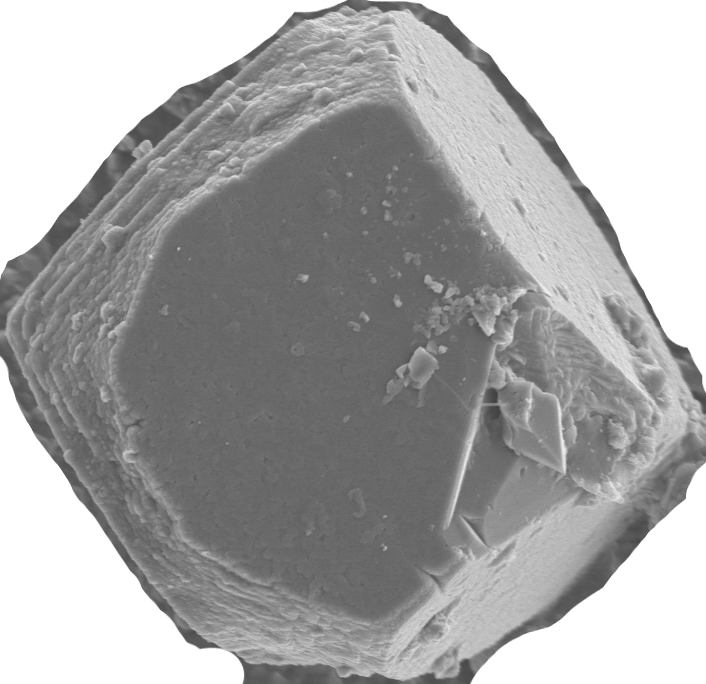
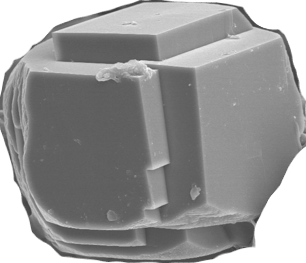
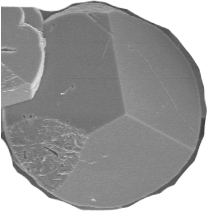

In [1]:
sample_dir = os.path.join('..', 'exemple label')
classes = ['cubic', 'pseudo-cubic', 'ball']

fig, axes = plt.subplots(1, 3, figsize=(8, 5))
for ax, cls in zip(axes, classes):
    files = [f for f in os.listdir(sample_dir) if f.startswith(cls)]
    if files:
        img = Image.open(os.path.join(sample_dir, files[0]))
        ax.imshow(img, cmap='gray')
        ax.set_title(cls, fontsize=14)
    ax.axis('off')

plt.suptitle('Example crystals : one per class', fontsize=16)
plt.tight_layout()
plt.show()

---
## 3. Data Augmentation

With only ~500 base SEM images, we supplemented the dataset with synthetic images.

**Technique : patch pasting:**
- Crop individual crystals as transparent PNG patches
- Paste them onto real SEM backgrounds at random position, rotation (0–360°), and scale (0.7–1.5×)
- Auto-generate YOLO bounding boxes from the paste coordinates

This is valid here because SEM images have no orientation prior : nanocrystals can appear at any angle.

In [ ]:
# Run from terminal:
# python src/data_augmentation.py --background background/background_1.png

# Or for a single class:
# python src/data_augmentation.py --classes cubic --seed 42

### 3.1 Visualization : augmented sample with YOLO label

`[requires local augmented output]`

<augmented sample>
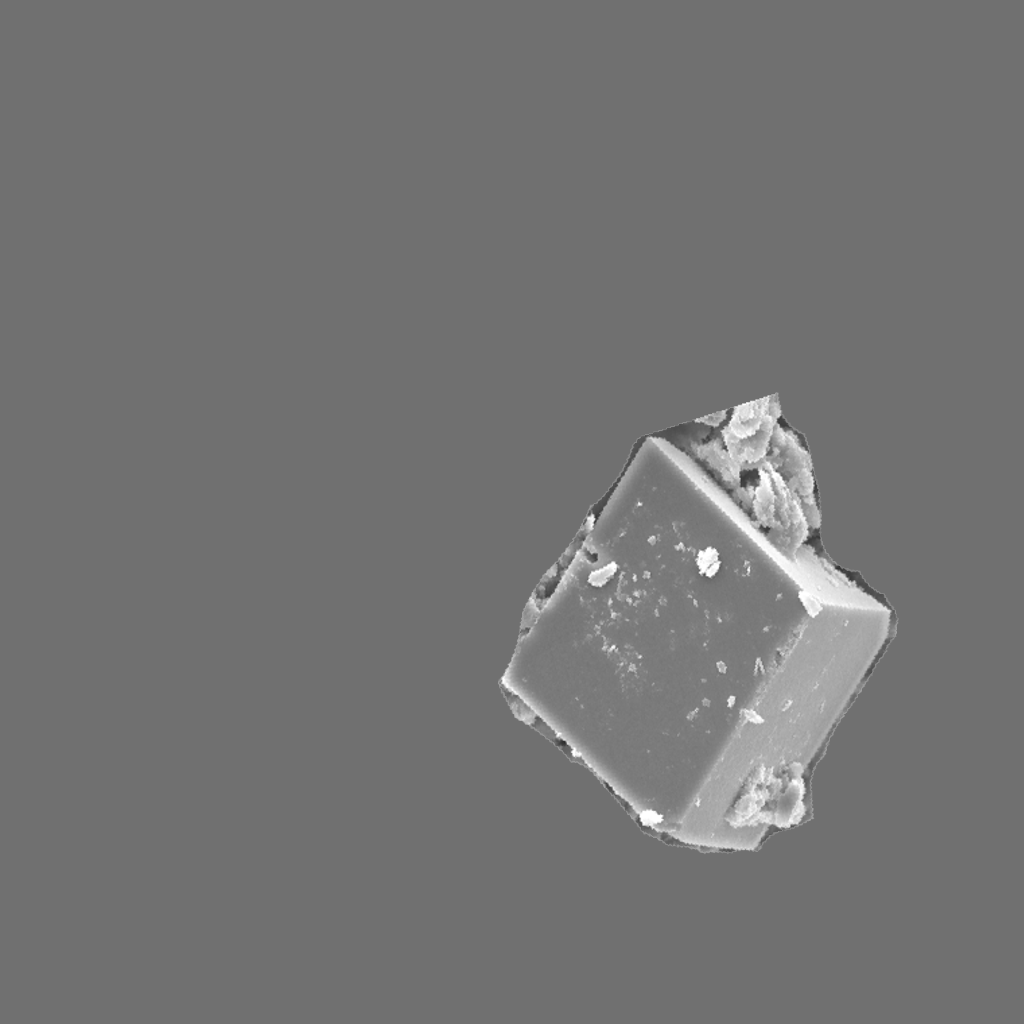

In [1]:
from PIL import ImageDraw

def show_yolo_label(image_path, label_path):
    image = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(image)
    w, h = image.size
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            _, xc, yc, bw, bh = map(float, parts)
            x1 = (xc - bw / 2) * w
            y1 = (yc - bh / 2) * h
            x2 = (xc + bw / 2) * w
            y2 = (yc + bh / 2) * h
            draw.rectangle([x1, y1, x2, y2], outline='red', width=3)
    plt.figure(figsize=(6, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title('Augmented image with YOLO label')
    plt.show()

# show_yolo_label('img_patch/cubic_0.png', 'txt/cubic_0.txt')

---
## 4. YOLOv8 Training

Training was run on Google Colab (T4 GPU). The `src/train_yolo.py` script reproduces the same configuration locally.

**Configuration:**

| Parameter | Value |
|-----------|-------|
| Model | YOLOv8n (nano) |
| Epochs | 30 |
| Batch size | 16 |
| Image size | 640 × 640 |
| Optimizer | Auto (SGD) |
| LR | 0.01 → 0.01 (cosine off) |
| Warmup | 3 epochs |

In [ ]:
# Run from terminal:
# python src/train_yolo.py --data data.yaml

# Or programmatically:
# from ultralytics import YOLO
# model = YOLO('yolov8n.pt')
# model.train(data='data.yaml', epochs=30, batch=16, imgsz=640)

---
## 5. Results

### 5.1 Training curves

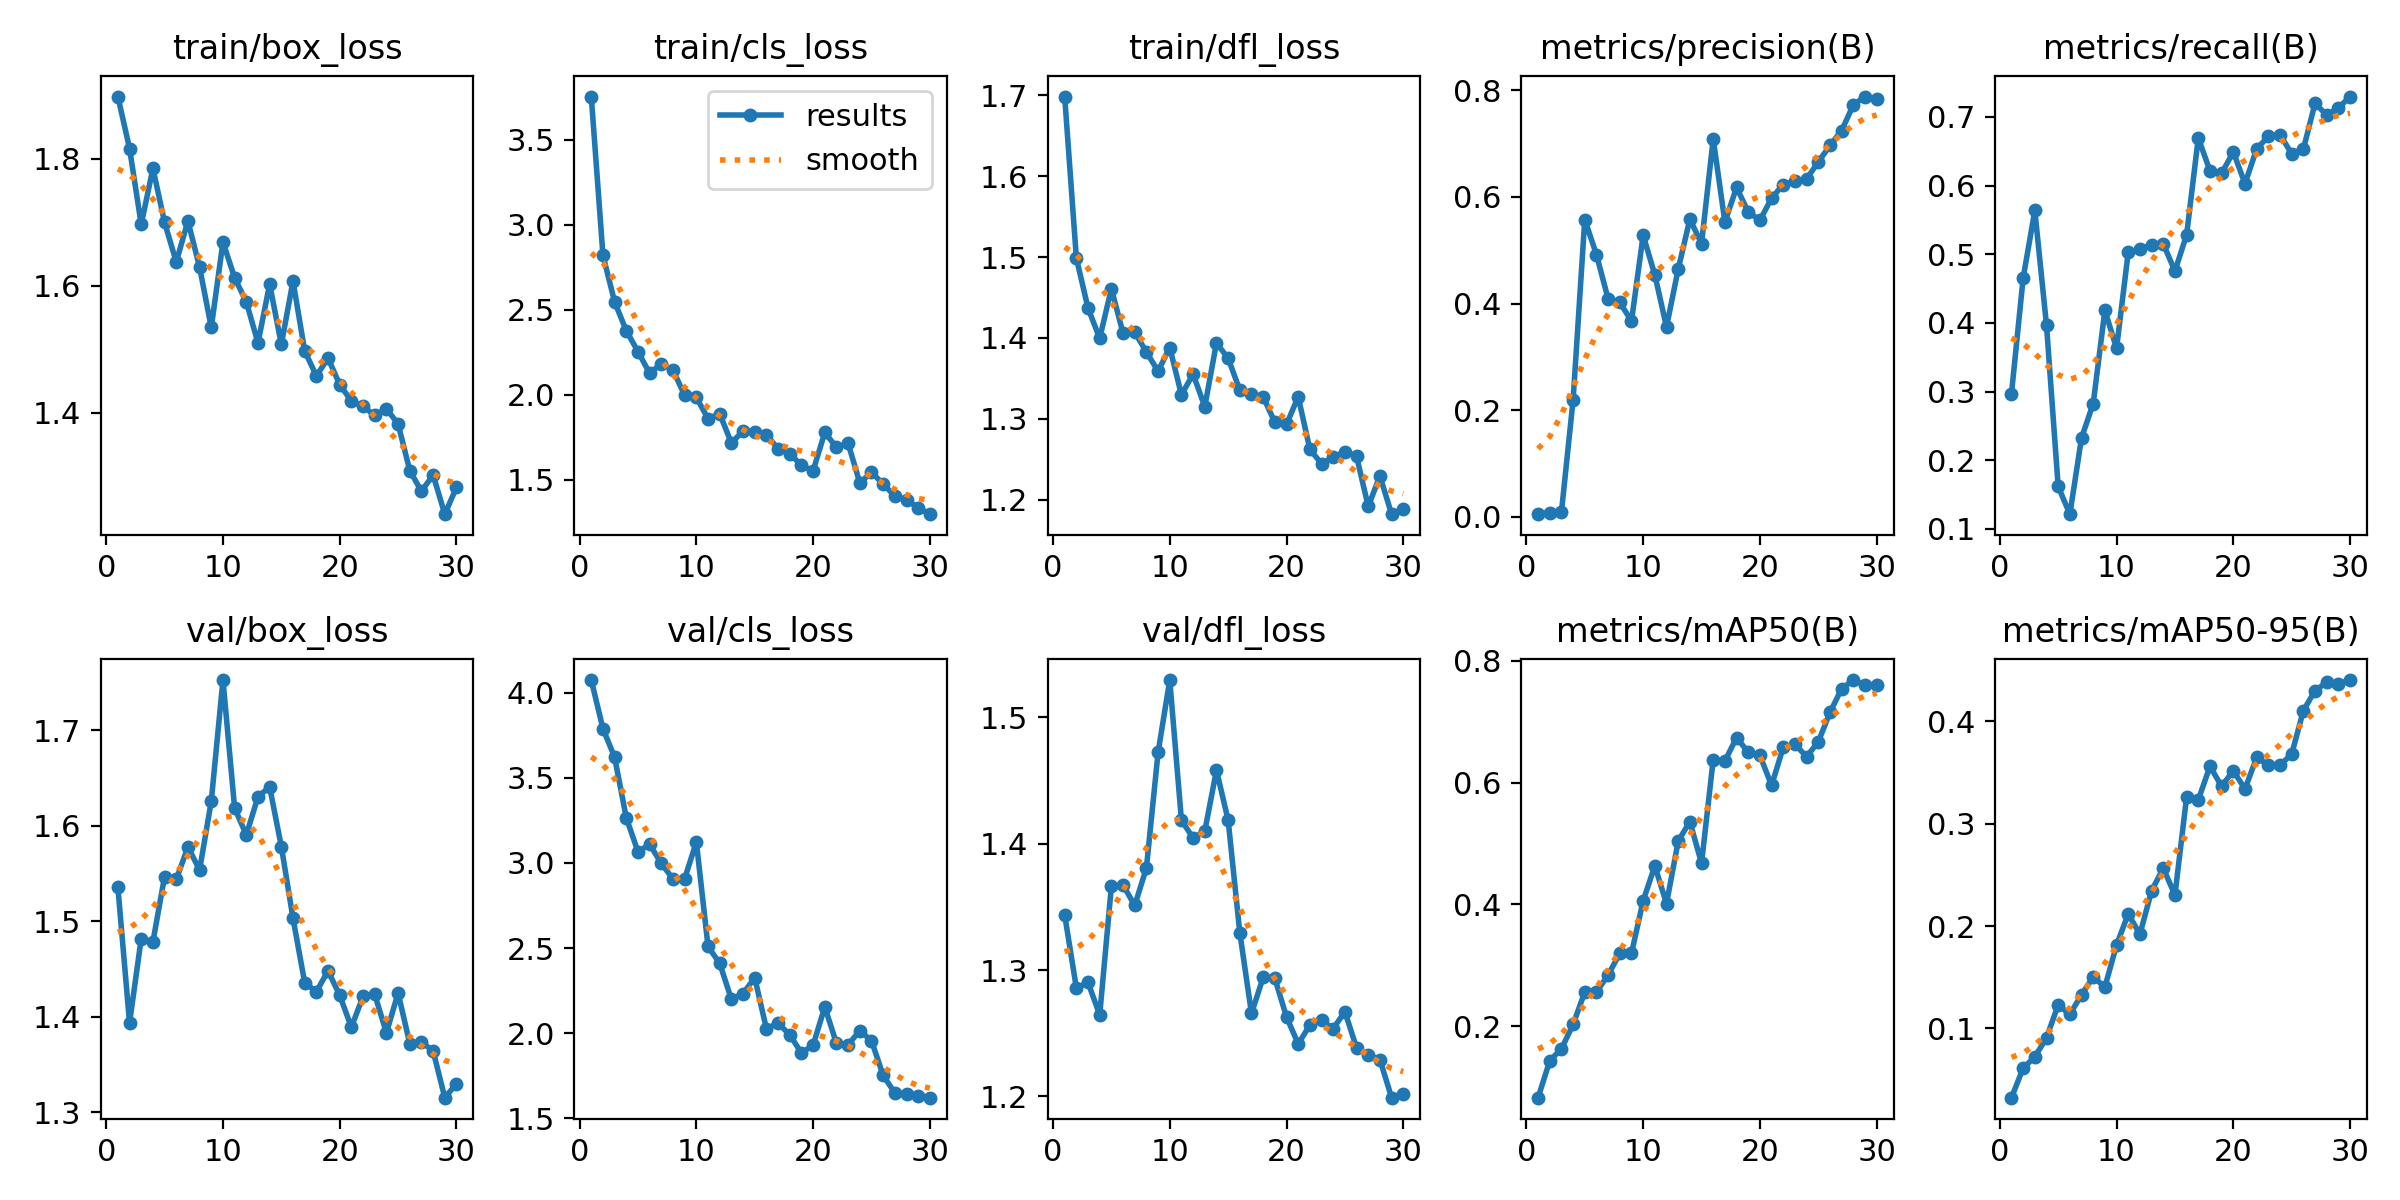

In [2]:
results_img = mpimg.imread(os.path.join('..', 'assets', 'results', 'results.png'))
plt.figure(figsize=(16, 8))
plt.imshow(results_img)
plt.axis('off')
plt.title('Training and validation curves (30 epochs)', fontsize=14)
plt.tight_layout()
plt.show()

### 5.2 Confusion matrix

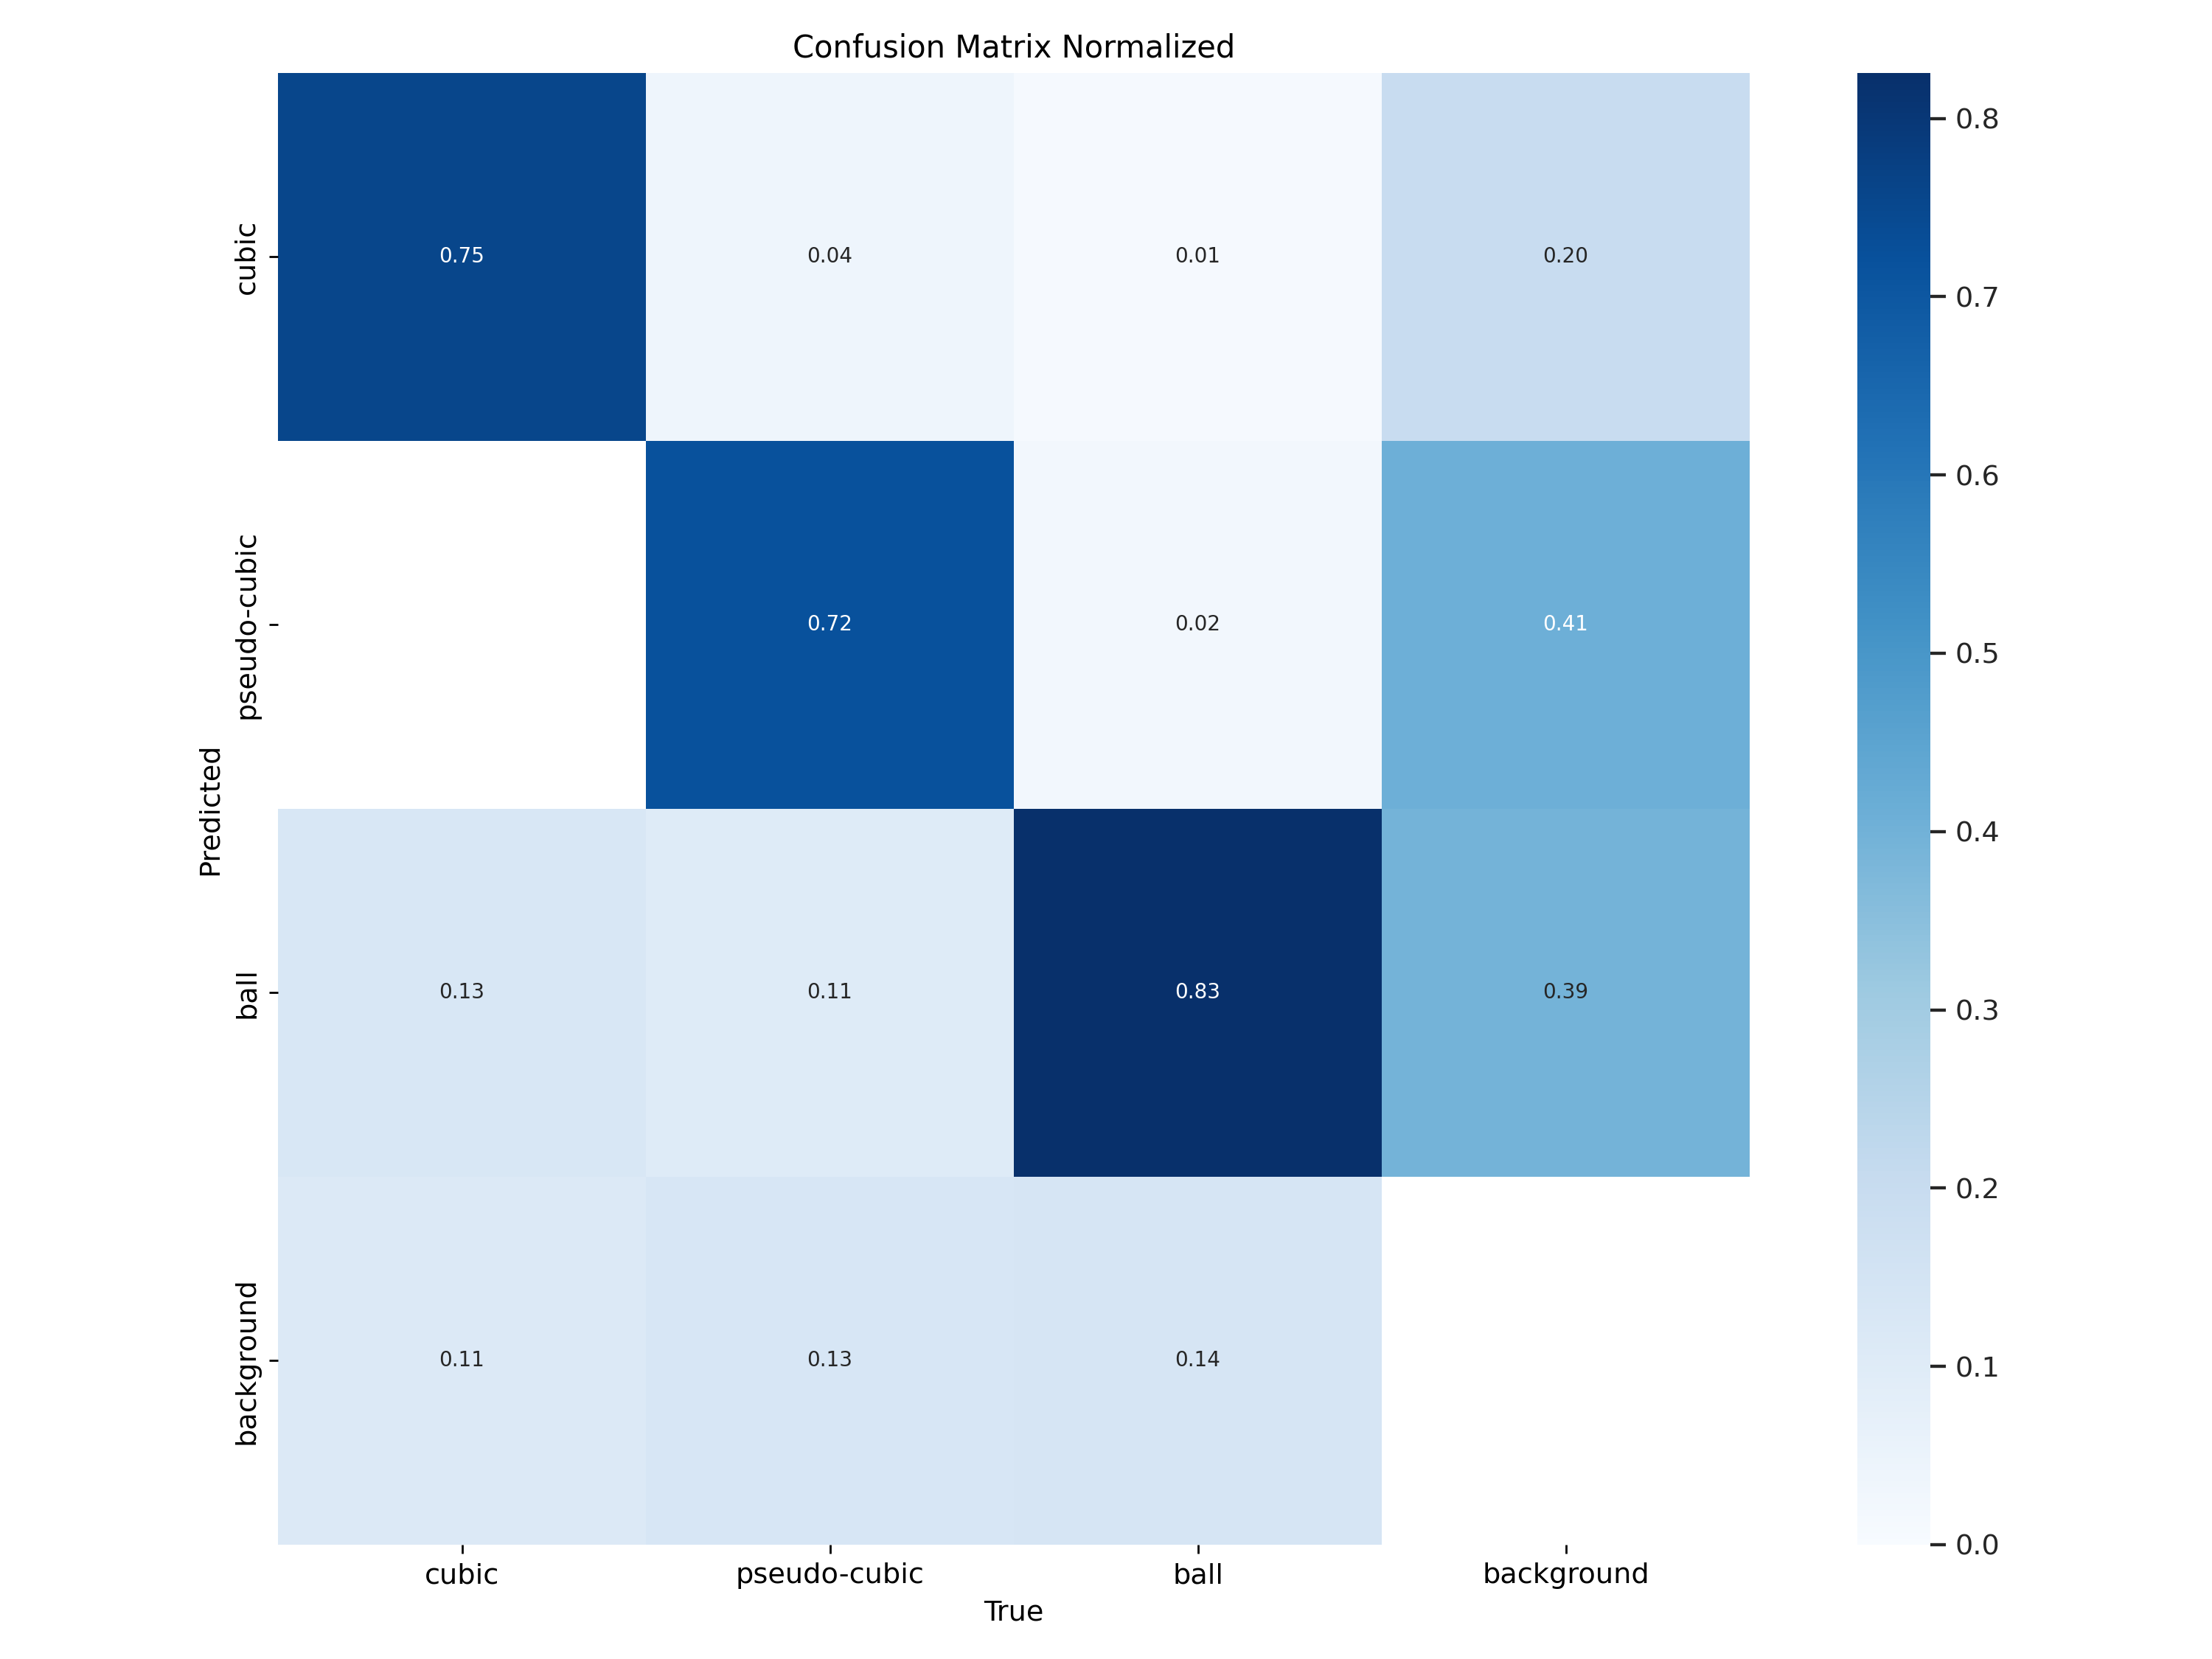

In [3]:
cm_img = mpimg.imread(os.path.join('..', 'assets', 'results', 'confusion_matrix_normalized.png'))
plt.figure(figsize=(8, 7))
plt.imshow(cm_img)
plt.axis('off')
plt.title('Normalized confusion matrix', fontsize=14)
plt.tight_layout()
plt.show()

### 5.3 Precision-Recall curve


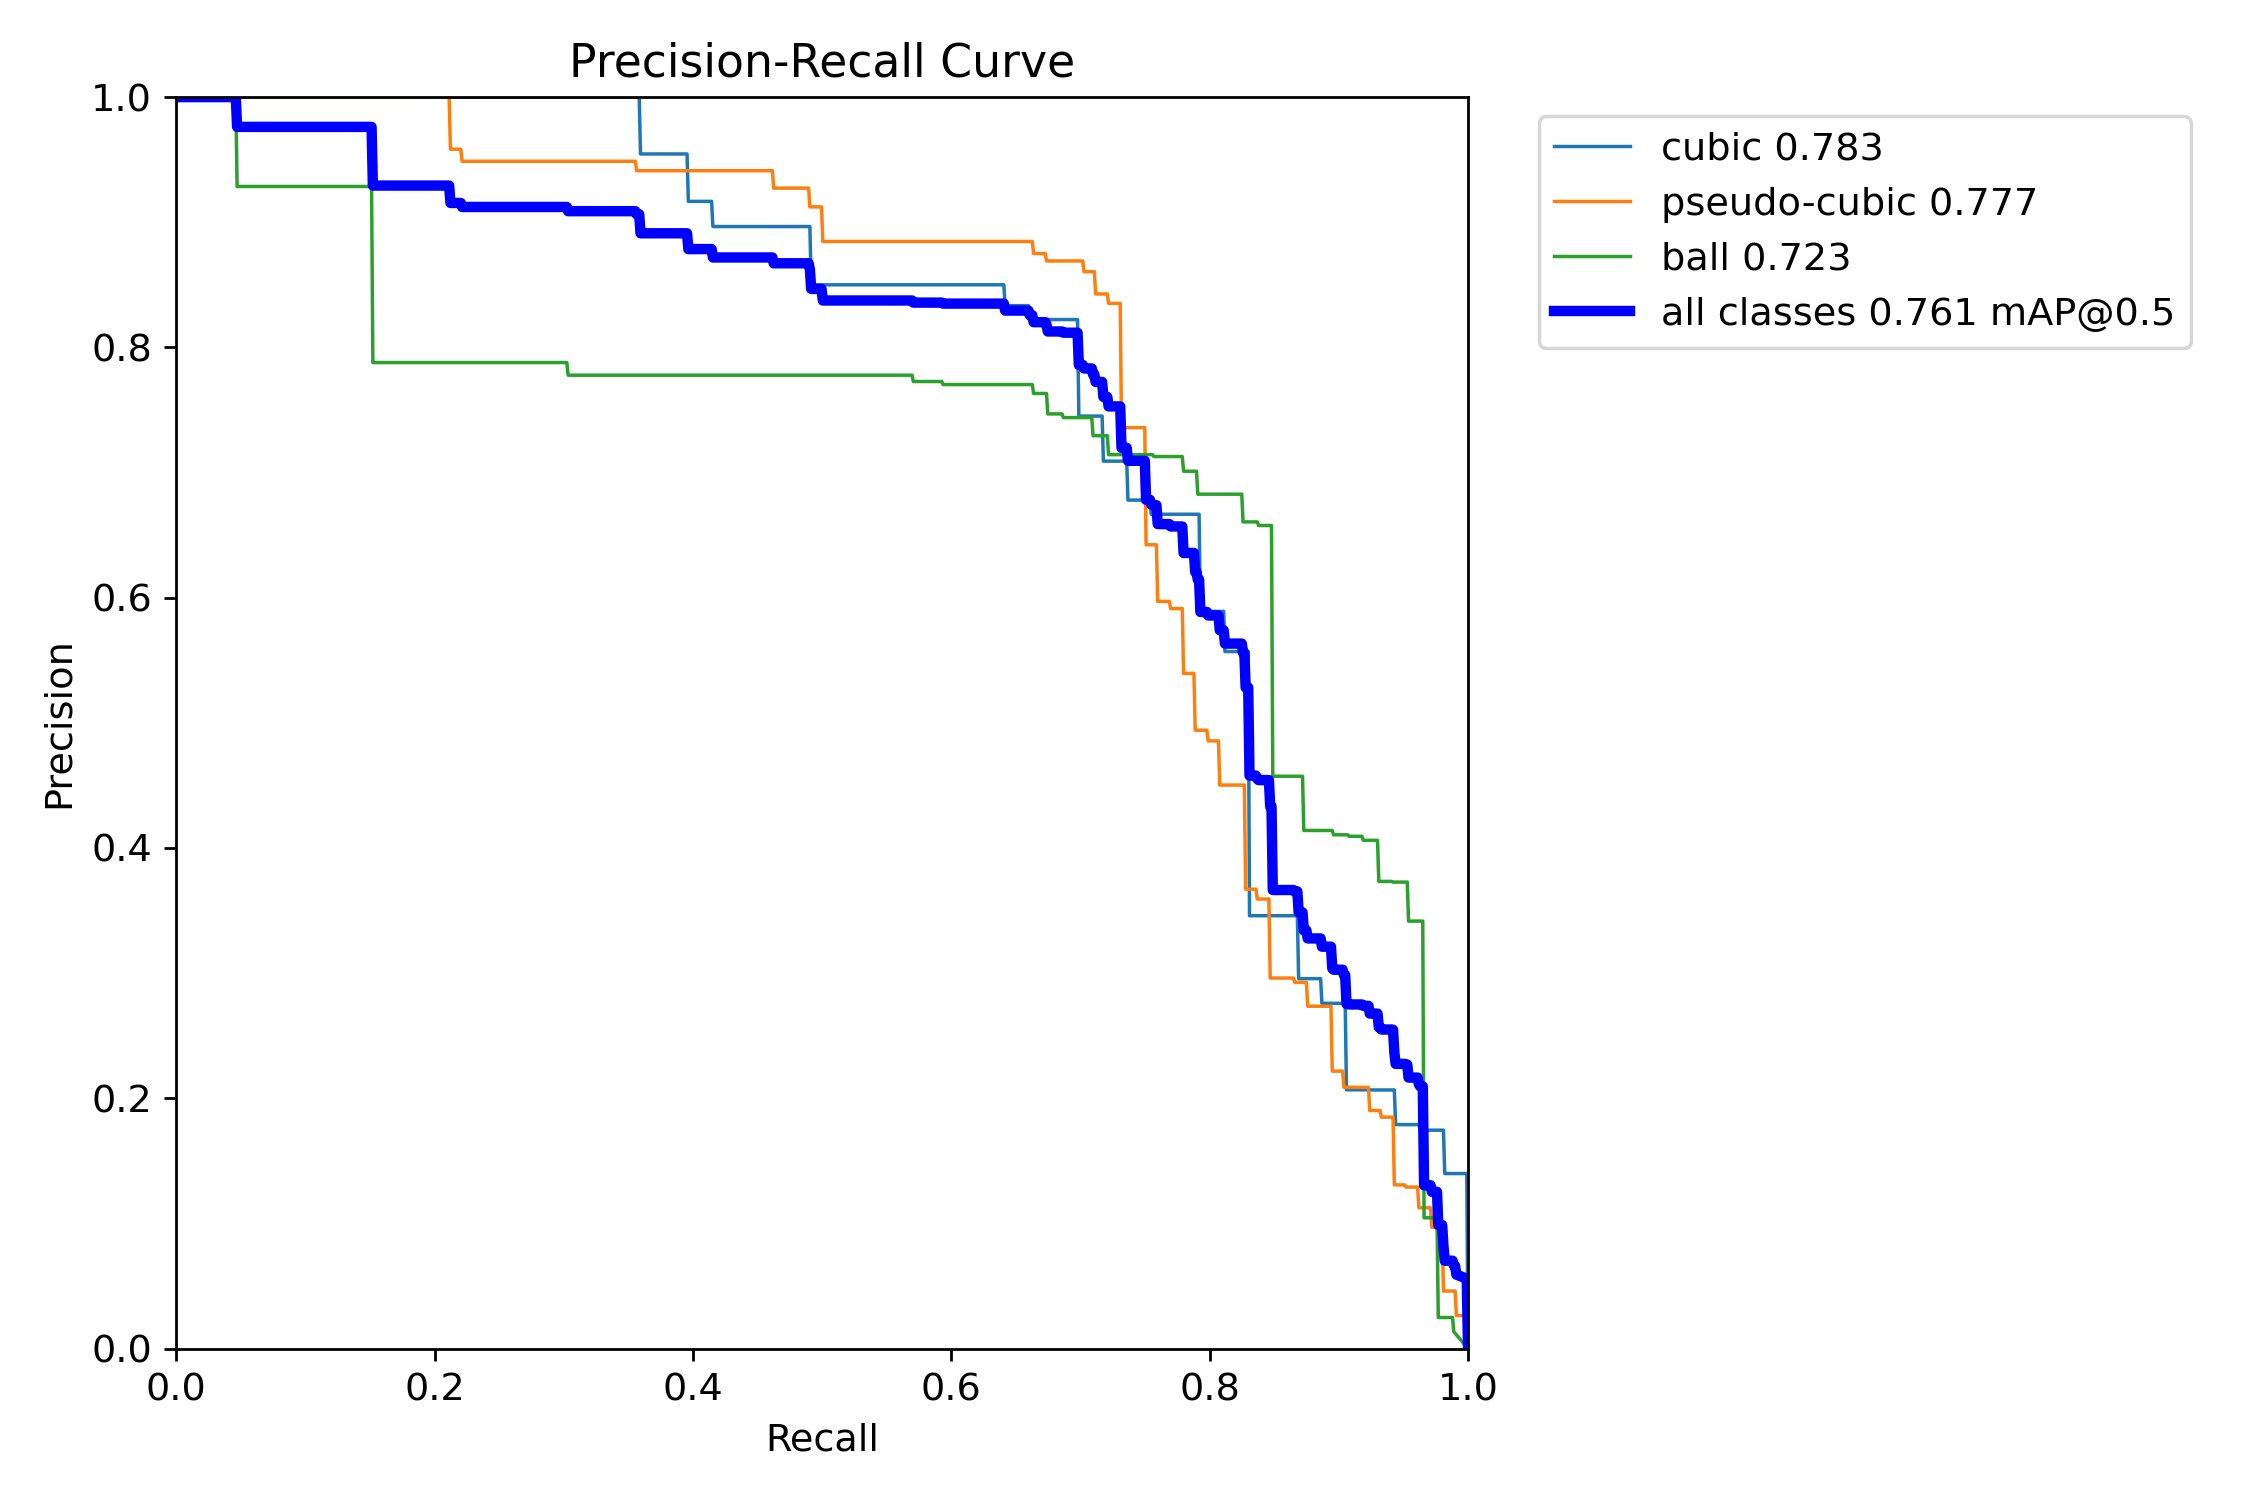
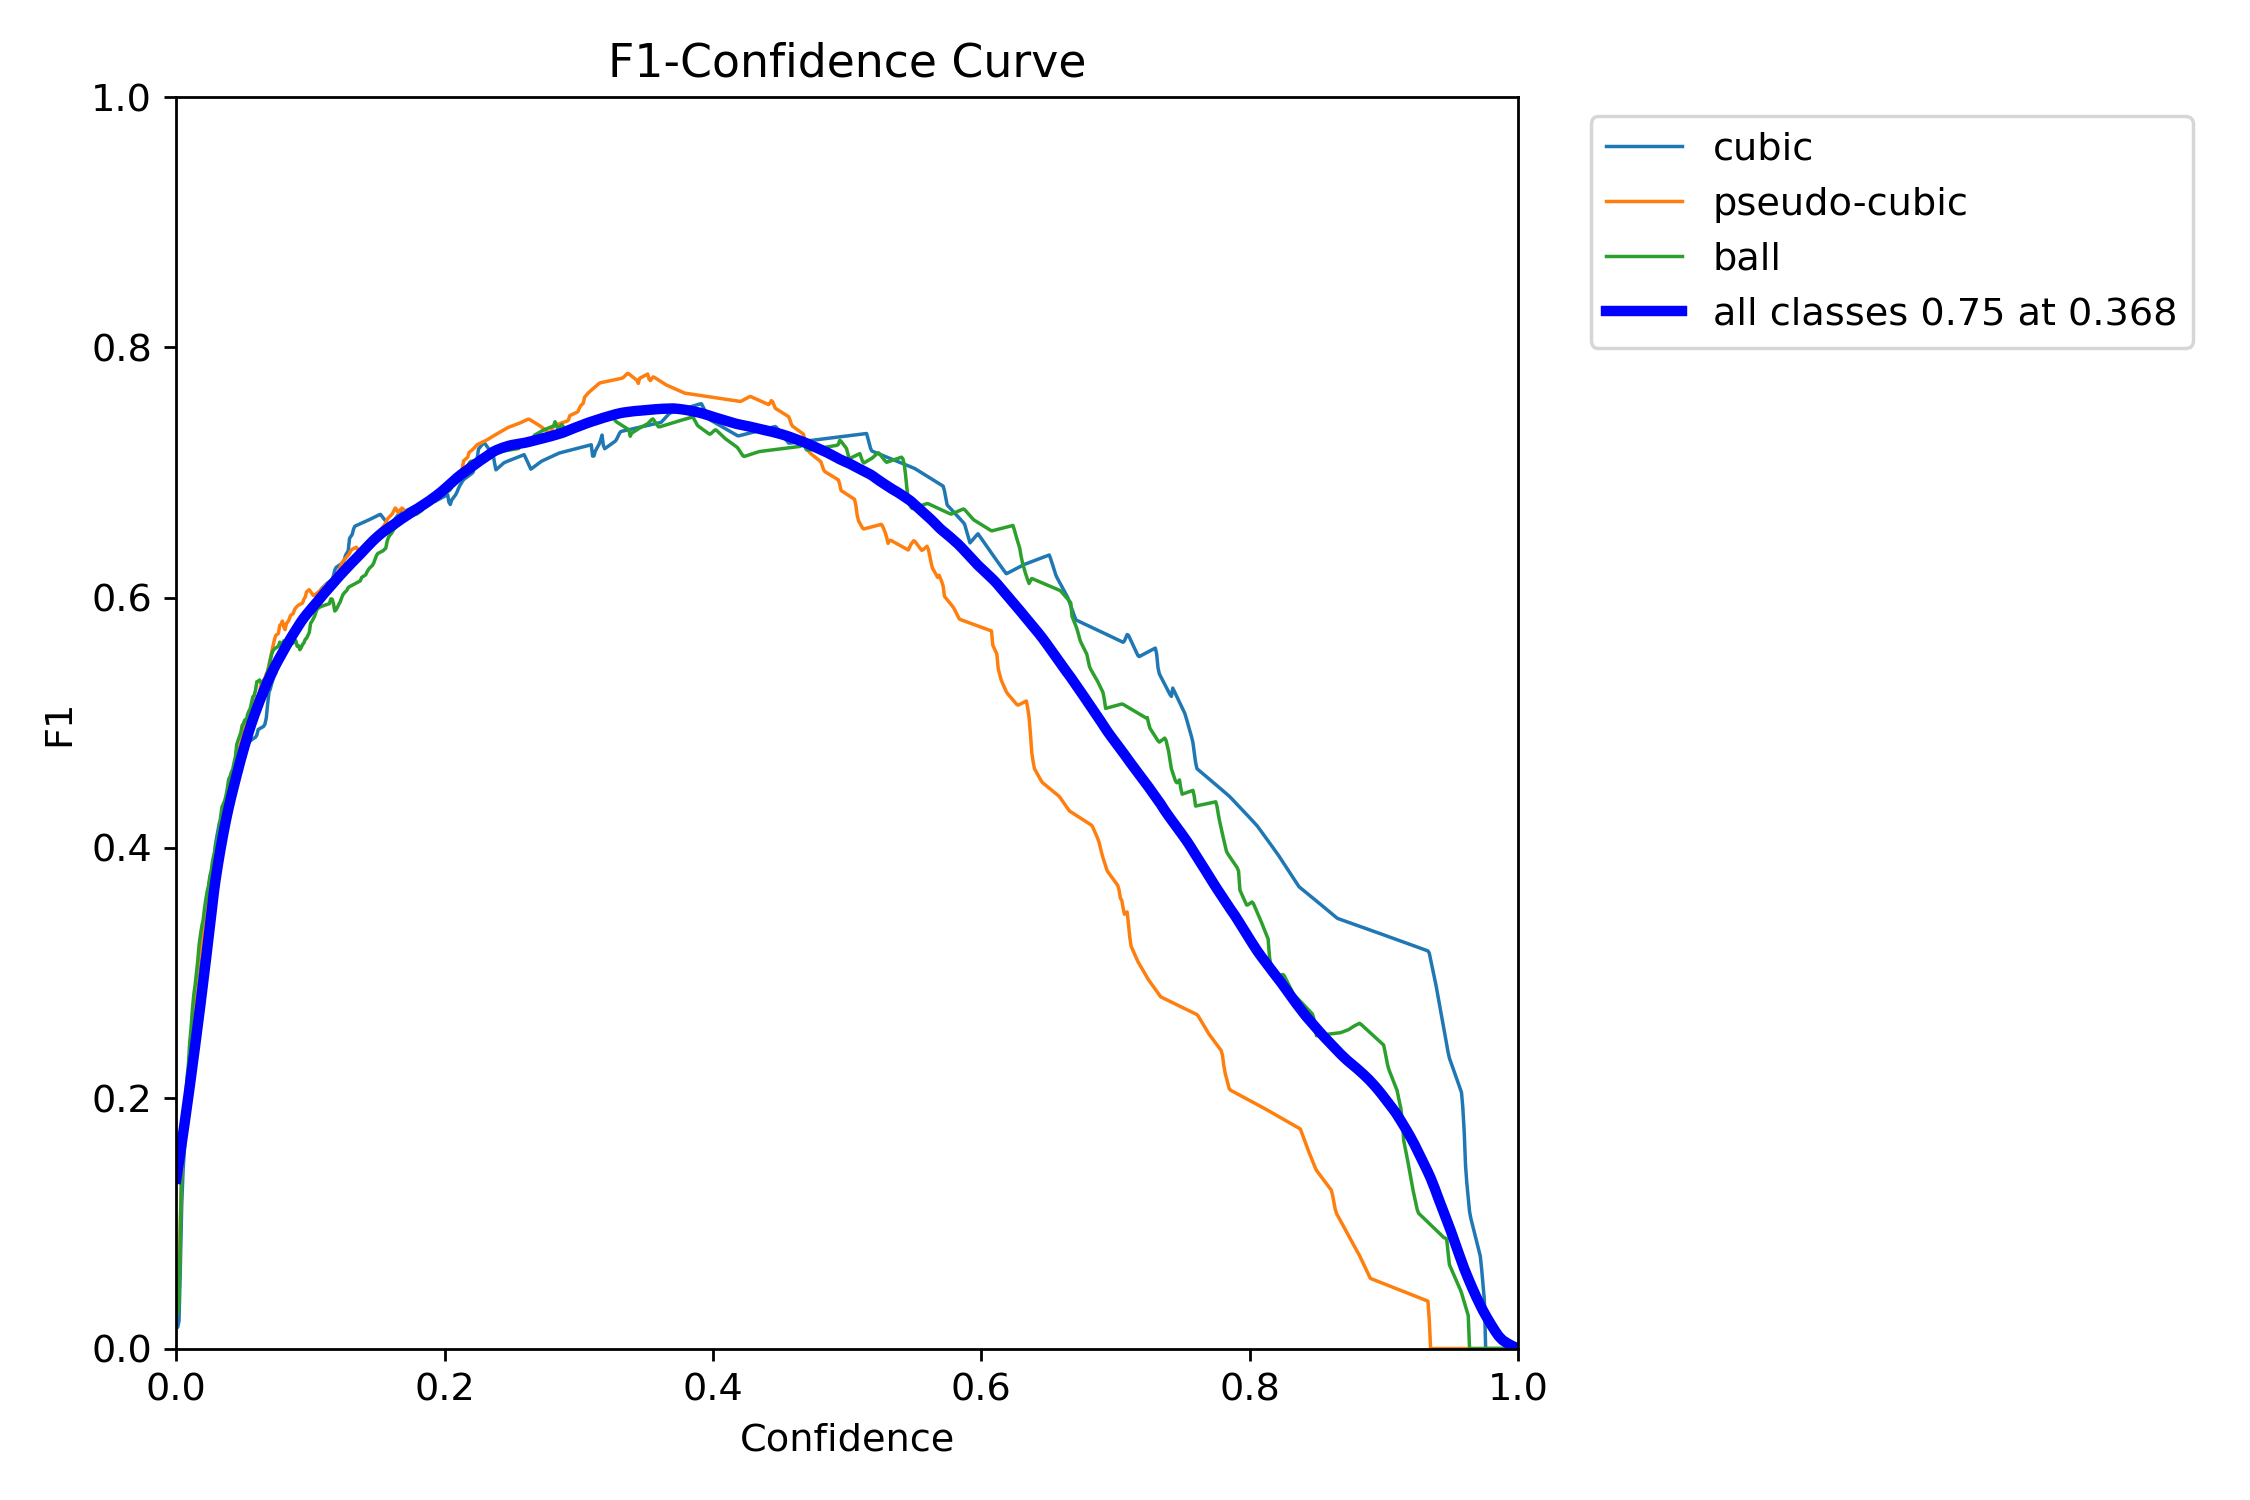
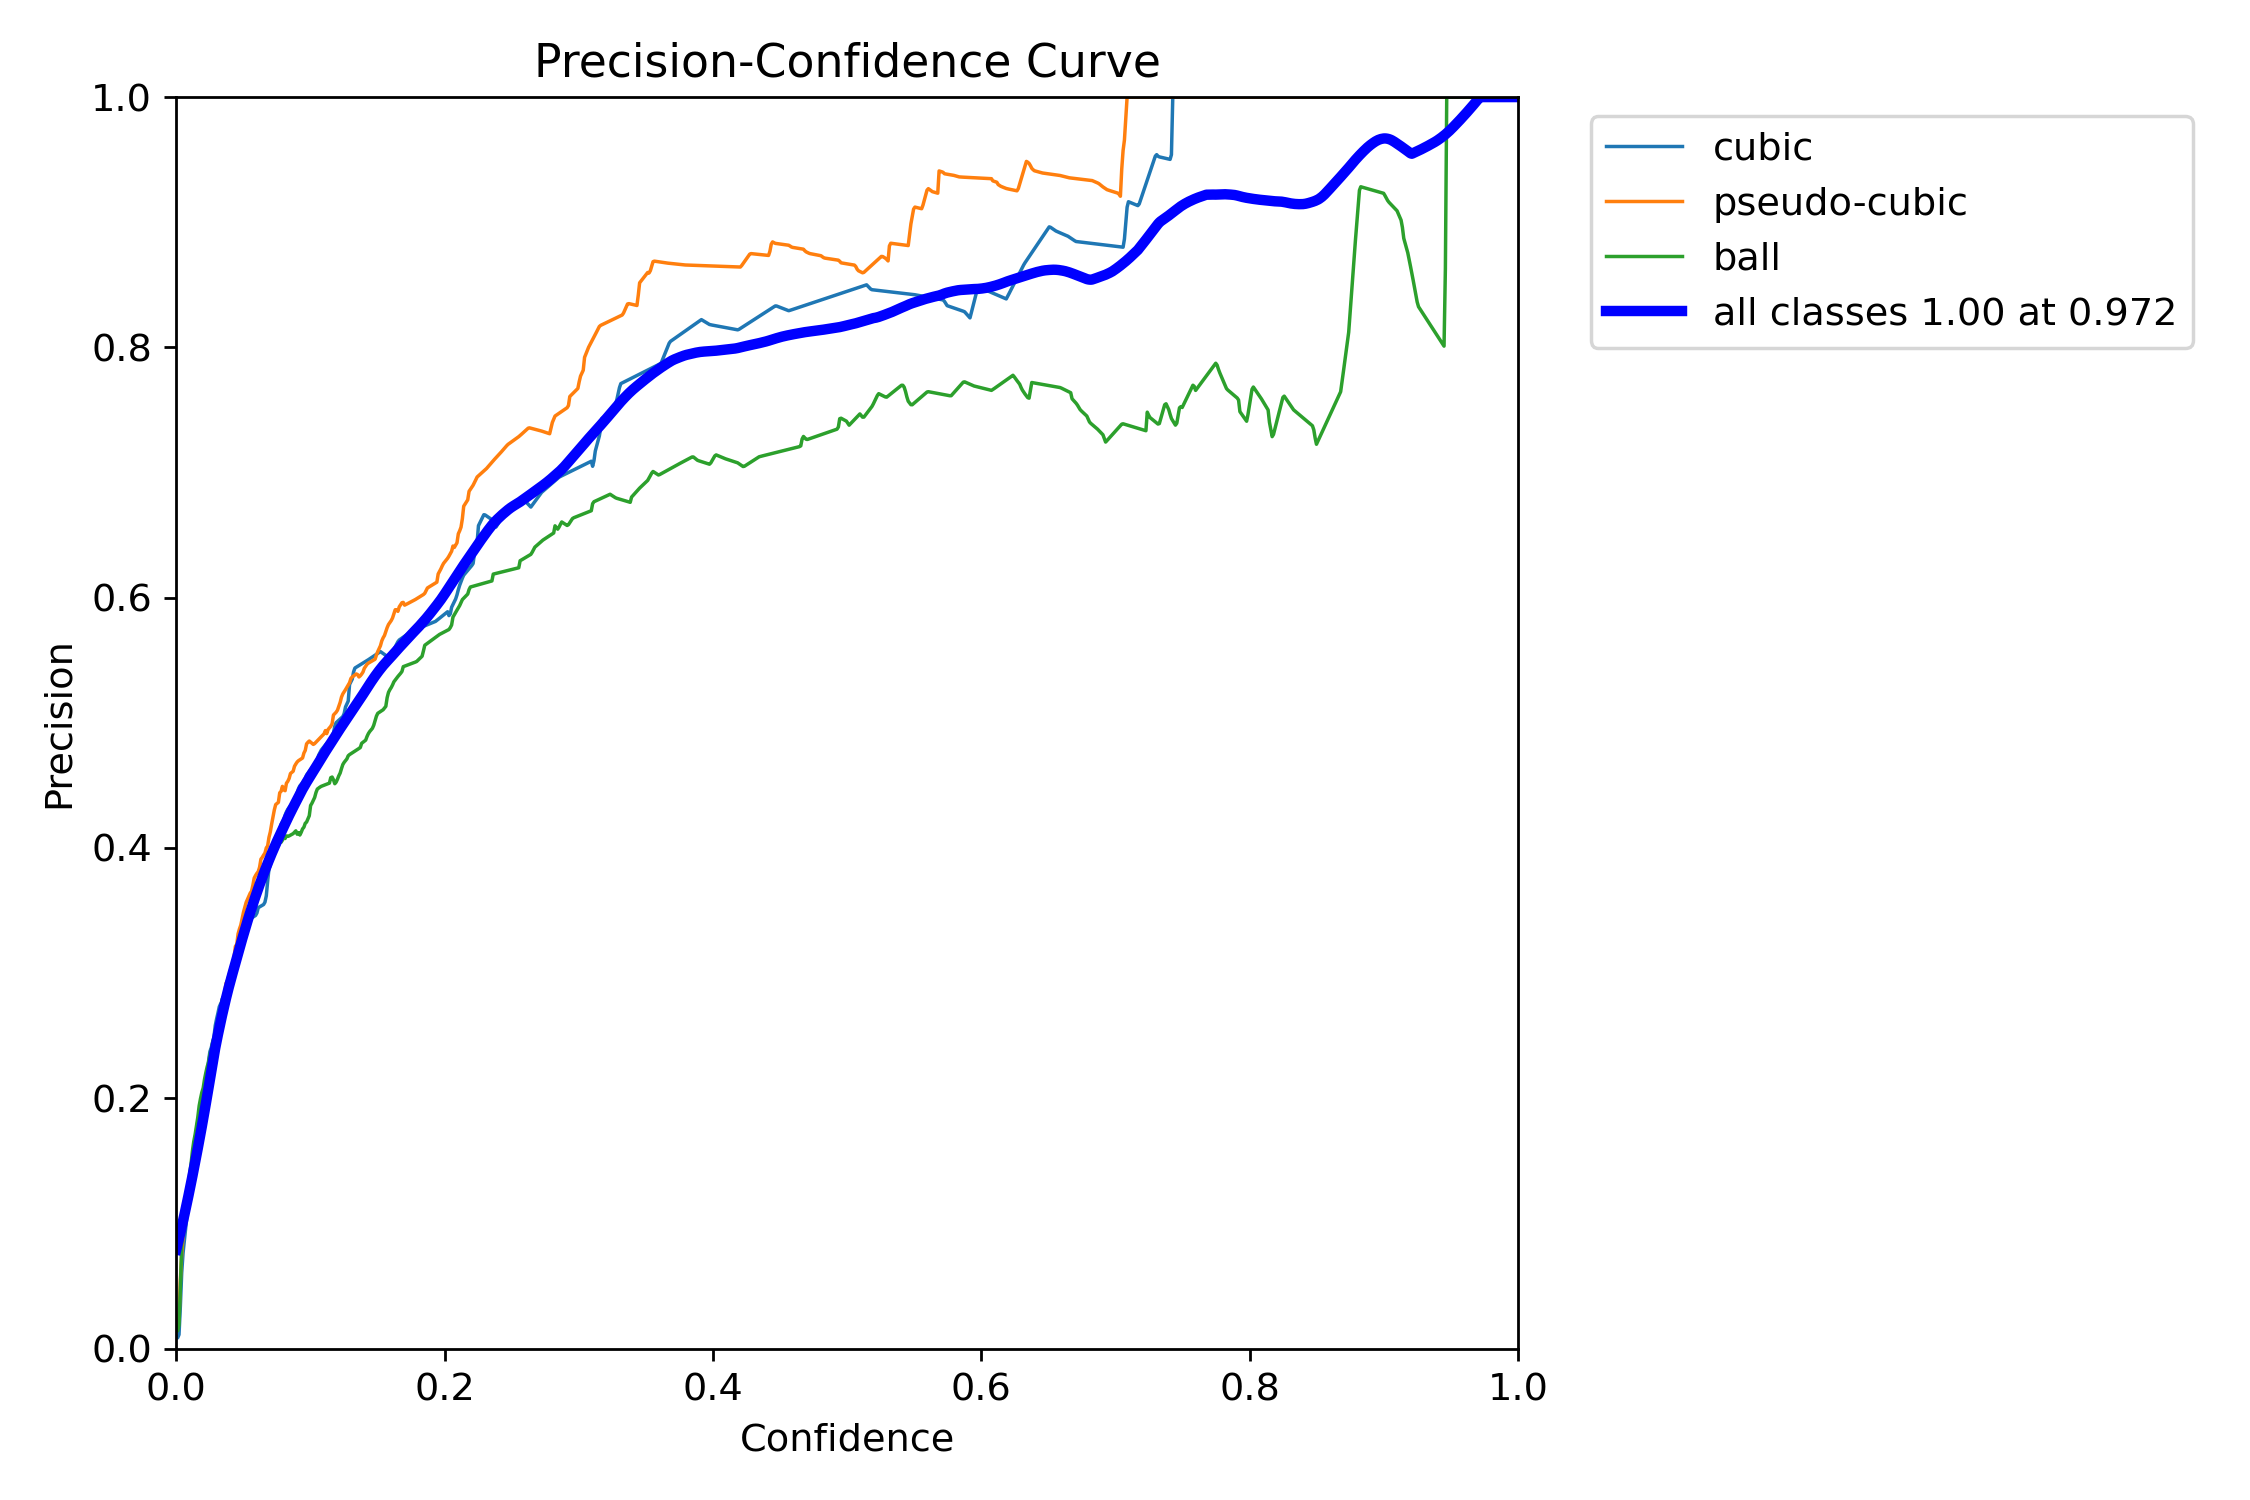
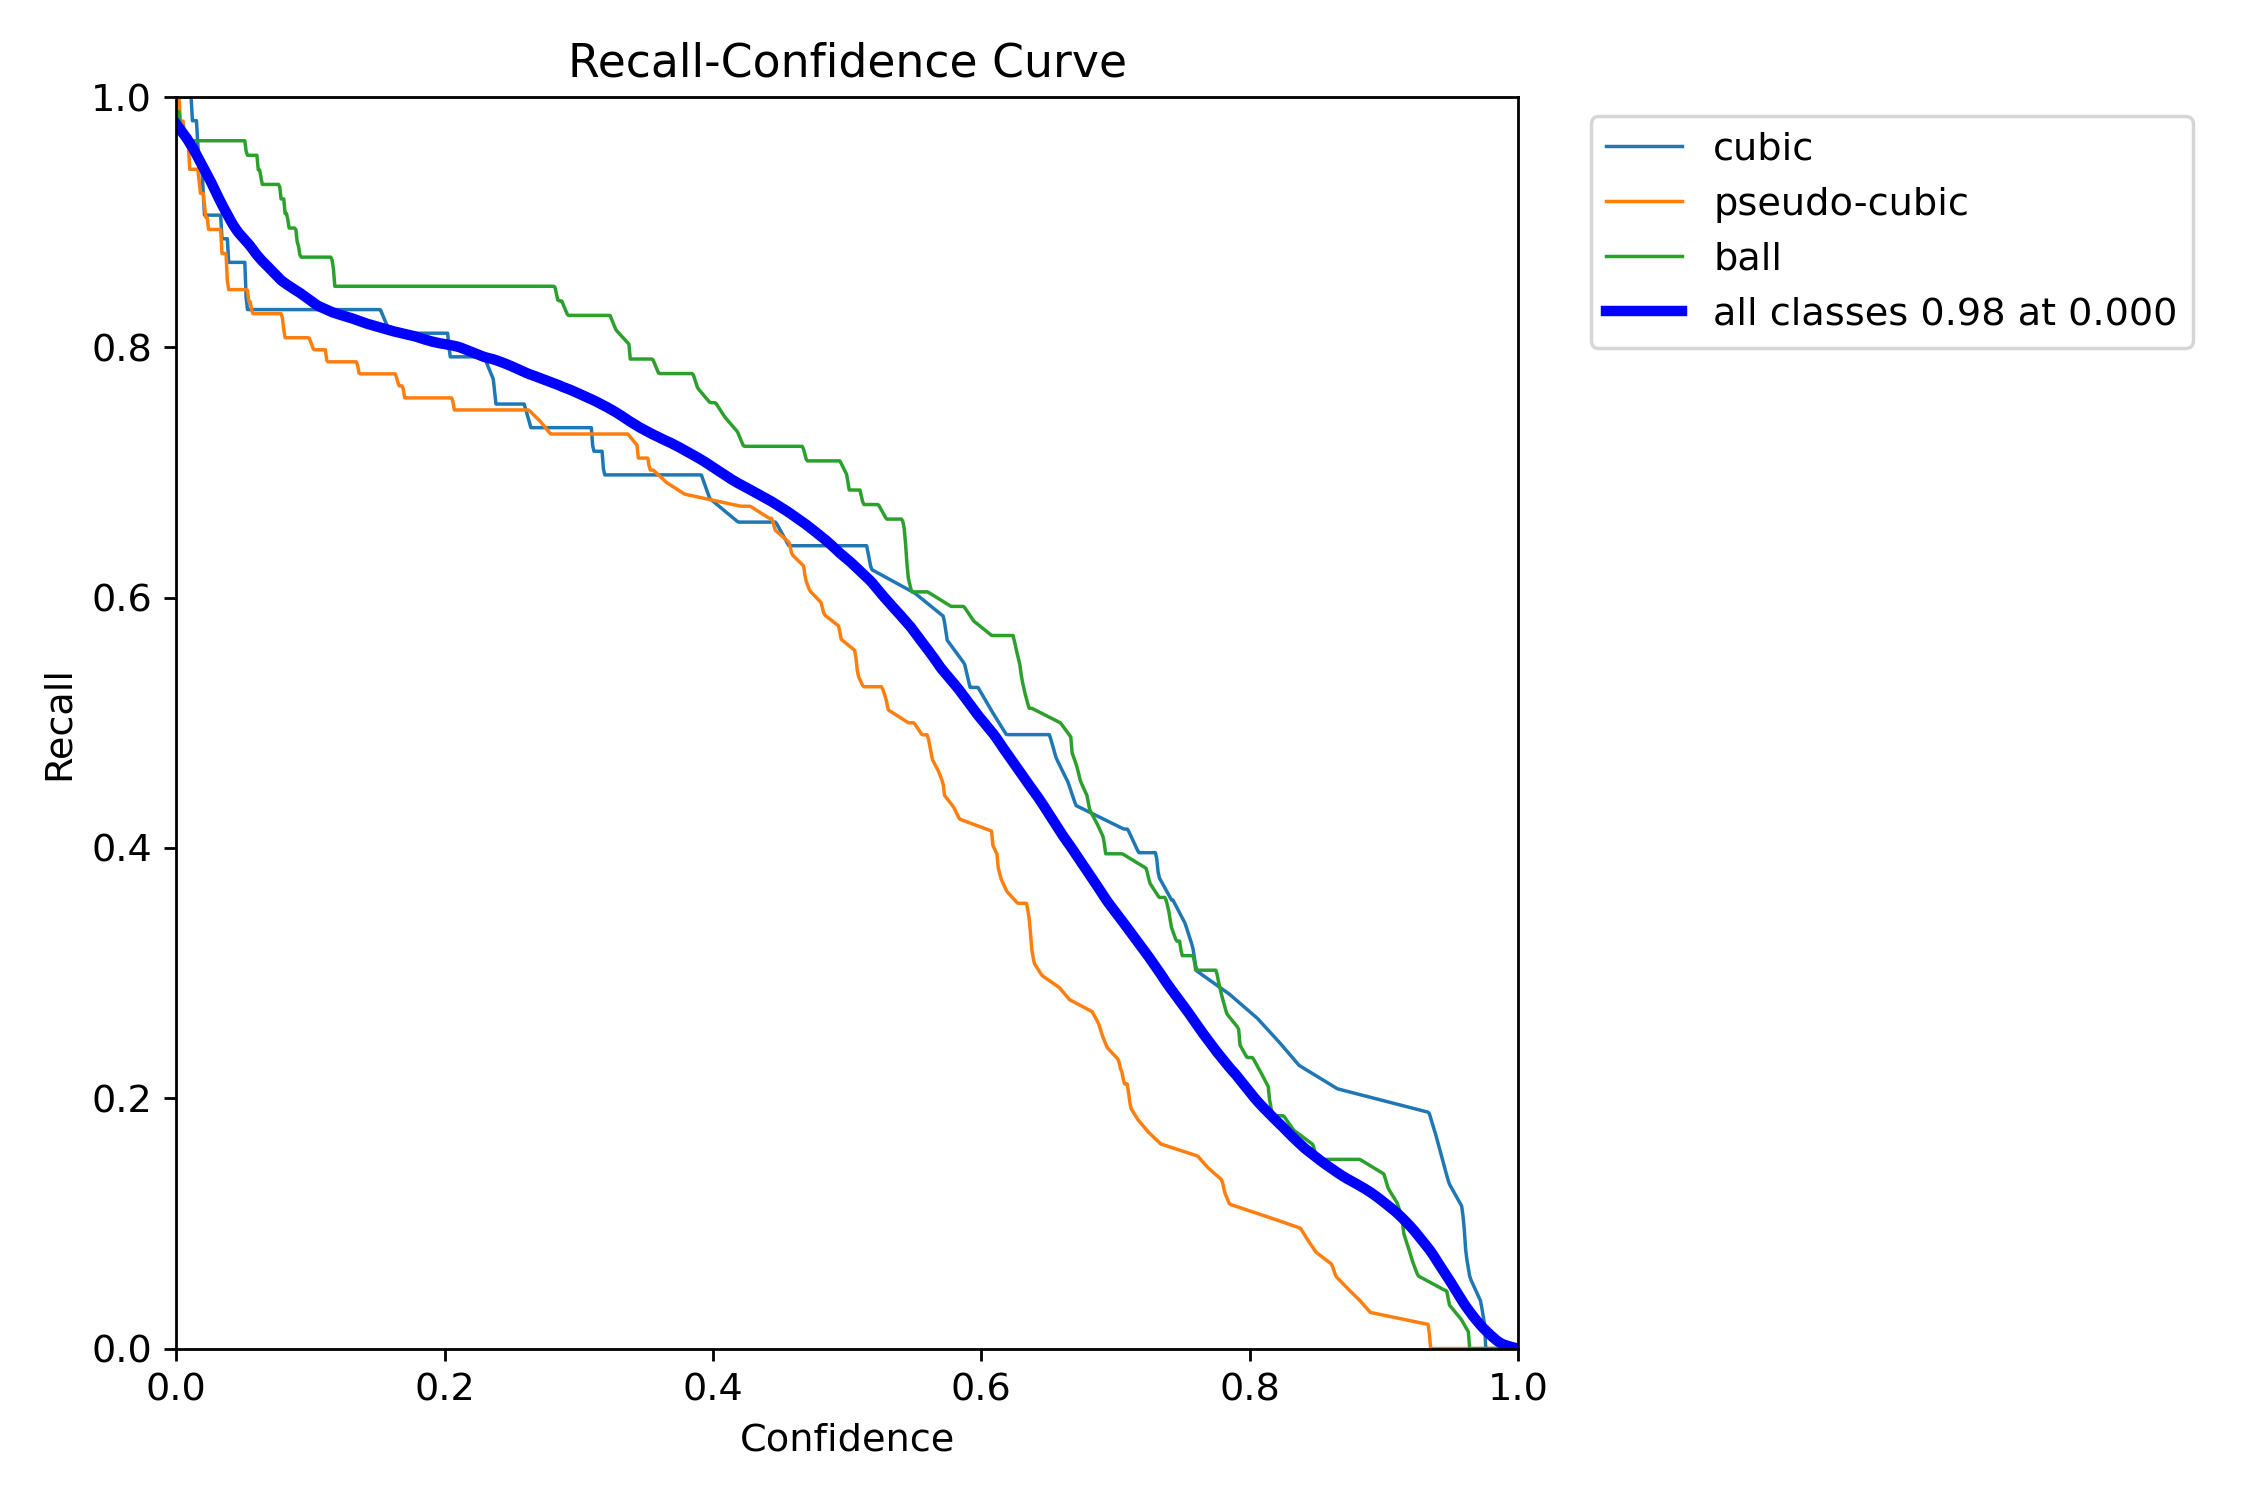

In [3]:
pr_img = mpimg.imread(os.path.join('..', 'assets', 'results', 'PR_curve.png'))
plt.figure(figsize=(8, 6))
plt.imshow(pr_img)
plt.axis('off')
plt.title('Precision-Recall curve', fontsize=14)
plt.tight_layout()
plt.show()

### 5.4 Metrics summary

 Best epoch (highest mAP@50): epoch 28
  mAP@50       0.7684
  mAP@50-95    0.4381
  Precision    0.7725
  Recall       0.7025

 Final epoch: epoch 30
  mAP@50       0.7604
  mAP@50-95    0.4404
  Precision    0.7841
  Recall       0.7296


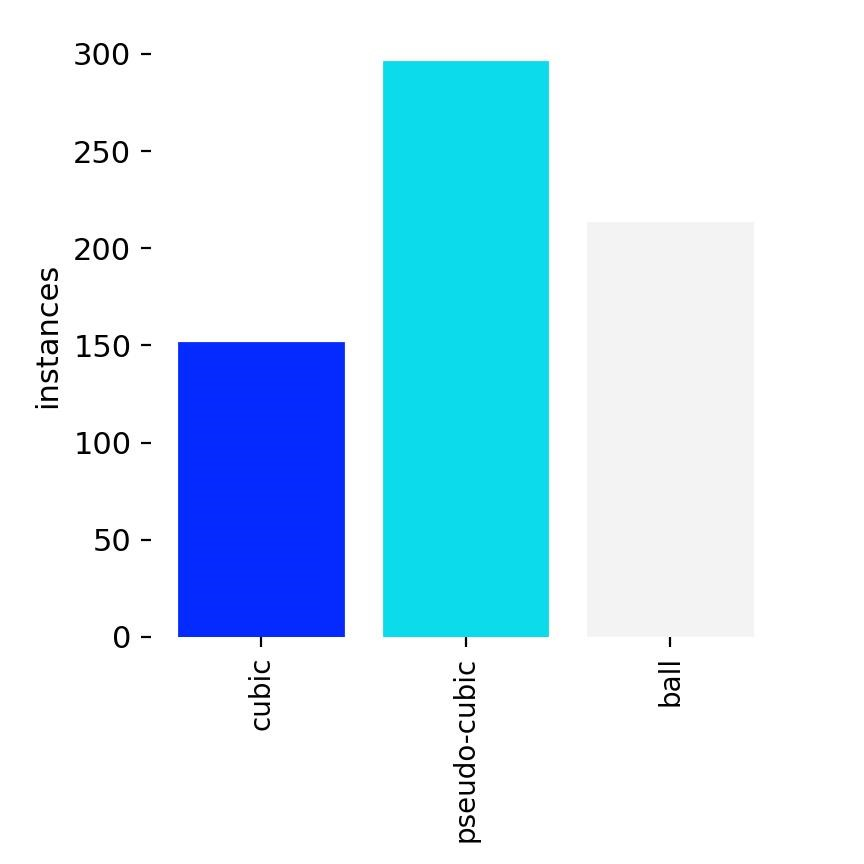

In [5]:
csv_path = os.path.join('..', 'yolo_results', 'train2', 'results.csv')
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# Plot mAP over epochs
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', linewidth=2)
axes[0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('mAP')
axes[0].set_title('mAP over training')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', linewidth=2)
axes[1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision & Recall over training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final metrics table
best_idx = df['metrics/mAP50(B)'].idxmax()
best = df.iloc[best_idx]
final = df.iloc[-1]

summary = pd.DataFrame({
    'Metric': ['mAP@50', 'mAP@50-95', 'Precision', 'Recall'],
    f'Best (epoch {int(best["epoch"])})': [
        f"{best['metrics/mAP50(B)']:.4f}",
        f"{best['metrics/mAP50-95(B)']:.4f}",
        f"{best['metrics/precision(B)']:.4f}",
        f"{best['metrics/recall(B)']:.4f}"
    ],
    f'Final (epoch {int(final["epoch"])})': [
        f"{final['metrics/mAP50(B)']:.4f}",
        f"{final['metrics/mAP50-95(B)']:.4f}",
        f"{final['metrics/precision(B)']:.4f}",
        f"{final['metrics/recall(B)']:.4f}"
    ],
}).set_index('Metric')

print(summary.to_string())

### 5.5 Inference on a sample image

`[requires dataset or own image]`


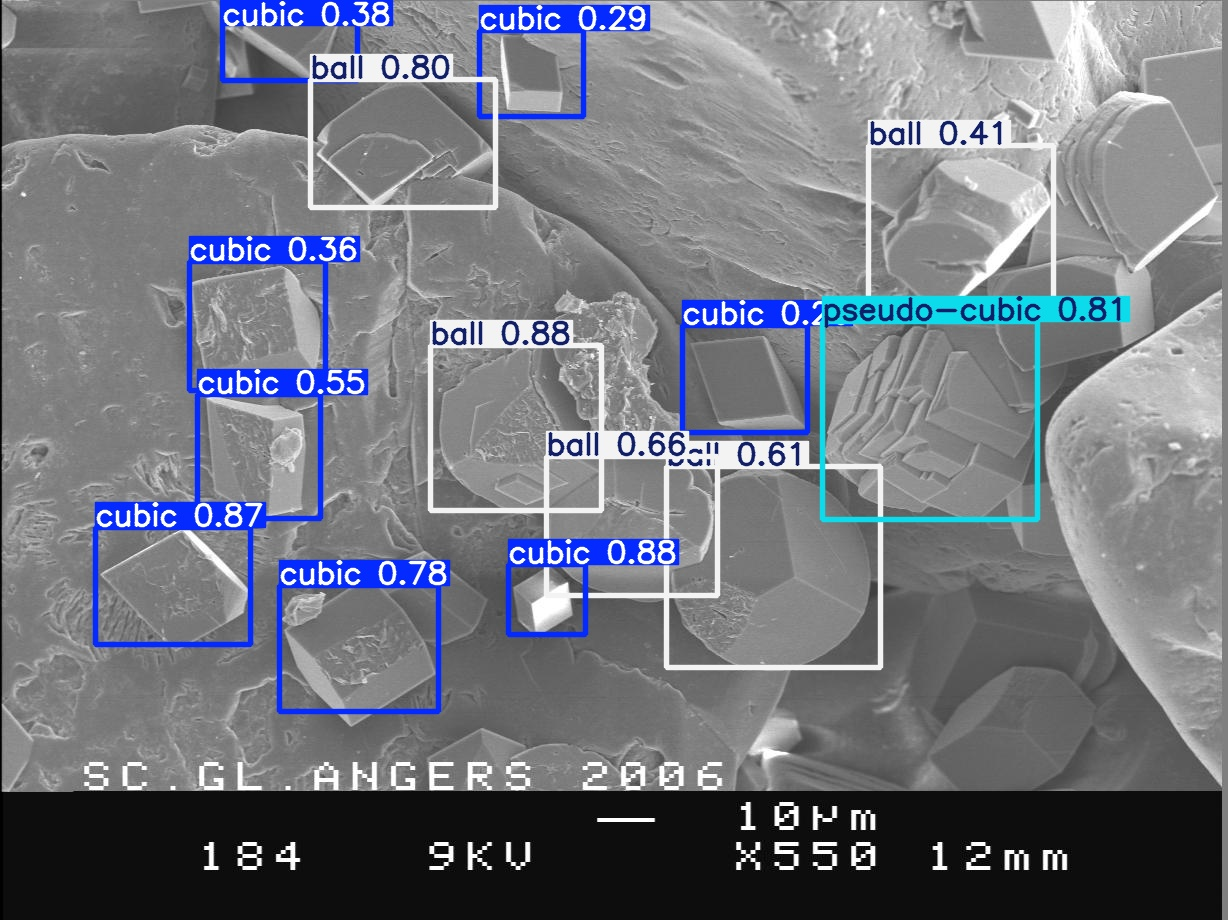
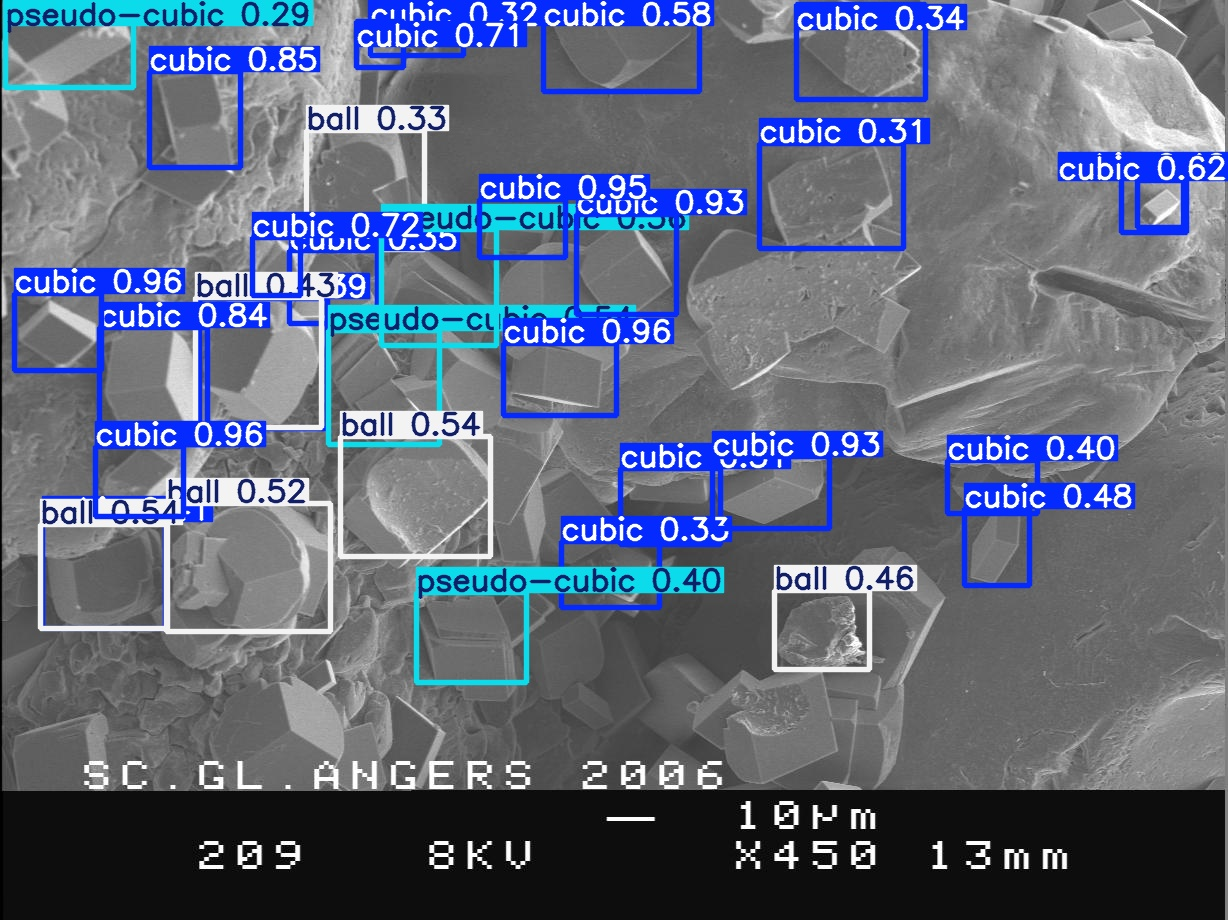

In [6]:
from ultralytics import YOLO

model = YOLO(os.path.join('..', 'yolo_results', 'train2', 'weights', 'best.pt'))

# Replace with the path to any SEM image
image_path = 'path/to/your/image.jpg'

results = model.predict(source=image_path, conf=0.25, verbose=False)
for result in results:
    annotated = result.plot(show=False)
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated[..., ::-1])
    plt.axis('off')
    plt.title('YOLOv8 detections')
    plt.show()

    counts = {}
    for box in result.boxes:
        name = result.names[int(box.cls.item())]
        counts[name] = counts.get(name, 0) + 1
    for cls, n in sorted(counts.items()):
        print(f'  {cls}: {n}')